# EDA - Telecom Custumer Churn

O setor de telecomunicações apresenta alta taxa de cancelamento de cliente, tornando essencial entender por que os clientes deixam a empresa. Esta EDA tem como objetivo identificar volume, qualidade, distribuição e data readlines que influenciam o churn, analisando dados demográficos, serviços contratados, informações de cobrança e dados da conta dos clientes.

### Importando Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Carregando os Dados


In [3]:
data = pd.read_csv('./content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
data

**Data Description**
* custumerID: Identificador unico dos clientes
* gender: Genero dos clientes
* SeniorCitizen: Indica se o cliente é idoso (0= Não, 1= Sim)
* Partner: Se o cliente possui ou não um parceiro
* Dependents: Se o cliente possui dependentes
* tenure: Numero de meses que o cliente ficou com a empresa
* PhoneService: Indica se o cliente tem um plano de telefone
* MultipleLines: Viabilidade para multiplas linhas de telefone
* InternetService: Tipo do plano de internet (DSL/Fiber optic/No)
* OnlineSecurity: Status online de segurança
* OnlineBackup: Status online de backup
* DeviceProtection: Plano de proteção de dispositivo
* TechSupport: Suporte tecnico
* StreamingTV: Acesso ao servisso de streaming de TV
* StreamingMovies: Acesso ao servisso de streaming de filmes
* Contract: Tipo de contrato
* PaperlessBilling: Fatura digital (Sim/Não)
* PaymentMethod: Metodo de pagamento
* MonthlyCharges: Recargas mensais
* TotalCharges: Total de recargas por cliente
* Churn: Indica se o cliente vai continuar com o serviço ou não (Sim/Não)

### Checagem dos Dados

In [ ]:
data.shape

In [ ]:
data.head()

In [ ]:
data.tail()

In [ ]:
data.columns

In [ ]:
data.dtypes

In [ ]:
# Informa dados sobre o uso de memória e valores ausentes
data.info

In [ ]:
# Colunas numéricas
num_col = data.select_dtypes(include= ['float64', 'int64'])
num_col

In [ ]:
# Colunas categóricas
cat_col = data.select_dtypes(include=['object'])
cat_col.columns

In [ ]:
# Distribuição dos dados numéricos
data.describe()

In [ ]:
# Distribuição dos dados categóricos
data.describe(include='object')

In [ ]:
# Encontrando valores unicos
# Pegando a lista de colunas categóricas, podemos utilizar um for para identificar quais colunas possuem valores unicos.
lst =['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn']
for cat in lst:
  print(cat)
  print(f'{data[cat].unique()}\n')

In [ ]:
# Limpando os dados vazios escondidos no dataframe
# np.nan -> Substitui os espaços em branco por NaN (Not a Number) do Numpy, padrão utilizado pelo Pandas para identificar dados oficialmente Nulos
data.replace({" ":np.nan})

**TotalCharges com data type errado**

In [24]:
# Mudando to data type de TotalChargers | Object -> Float64
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [25]:
data.loc[:,'TotalCharges'].dtype

dtype('float64')

In [26]:
# Checando se há duplicatas
data.duplicated().sum()

np.int64(0)

In [108]:
# Checando se há valores vazios
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [106]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

Este código calcula a mediana da coluna TotalCharges e a utiliza para preencher os valores ausentes. 

Os valores ausentes precisam ser tratados porque a maioria dos algoritmos de Machine Learning não aceita dados nulos como entrada. Usamos a mediana em vez da média porque ela não é afetada por valores muito altos, representando melhor o cliente "típico" da base.

In [107]:
print(data['TotalCharges'].isnull().sum())

0


# Análise dos Dados

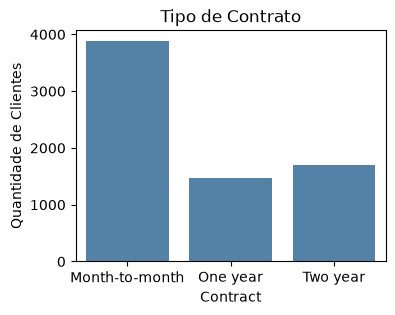

In [149]:
plt.figure(figsize=(4,3))
sns.countplot(data, x='Contract', color='steelblue')
plt.title('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

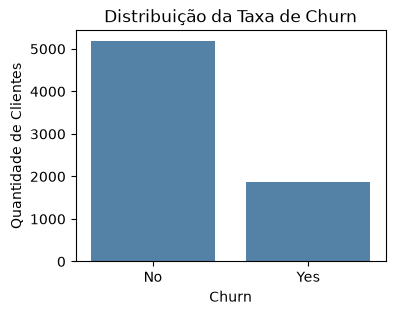

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(data, x='Churn', color='steelblue')
plt.ylabel('Quantidade de Clientes')
plt.title('Distribuição da Taxa de Churn')
plt.show()

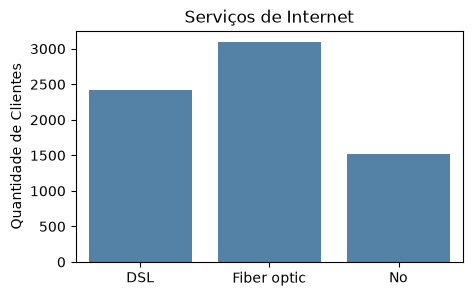

In [100]:
plt.figure(figsize=(5,3))
sns.countplot(data, x='InternetService', color='steelblue')
plt.ylabel('Quantidade de Clientes')
plt.xlabel(None)
plt.title('Serviços de Internet')


plt.show()

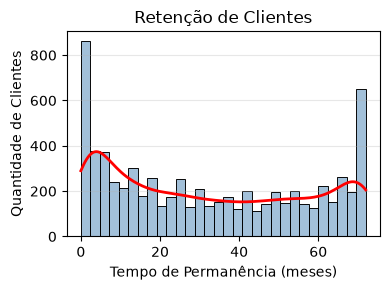

In [150]:
plt.figure(figsize=(4,3))
ax = sns.histplot(data['tenure'], bins=30, kde=True, color='steelblue')

ax.lines[0].set_color('red')
ax.lines[0].set_linewidth(2)
plt.title('Retenção de Clientes')
plt.xlabel('Tempo de Permanência (meses)')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

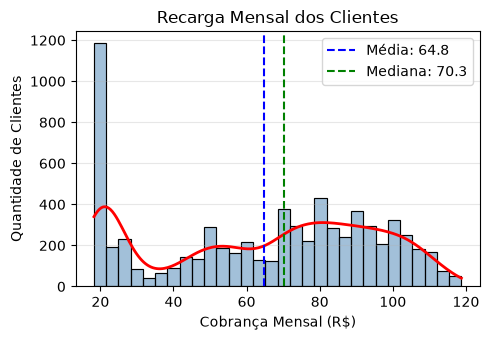

In [151]:
plt.figure(figsize=(5,3.5))
ax = sns.histplot(data['MonthlyCharges'], bins=30, kde=True, color='steelblue')

ax.lines[0].set_color('red')
ax.lines[0].set_linewidth(2)

media = data['MonthlyCharges'].mean()
mediana = data['MonthlyCharges'].median()
plt.axvline(media, color='blue', linestyle='--', linewidth=1.5, label=f'Média: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.1f}')

plt.title('Recarga Mensal dos Clientes')
plt.xlabel('Cobrança Mensal (R$)')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

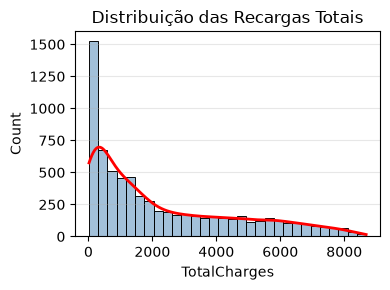

In [152]:
plt.figure(figsize=(4,3))
ax = sns.histplot(data['TotalCharges'], bins=30, kde=True, color='steelblue')

ax.lines[0].set_color('red')
ax.lines[0].set_linewidth(2)
plt.title('Distribuição das Recargas Totais')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

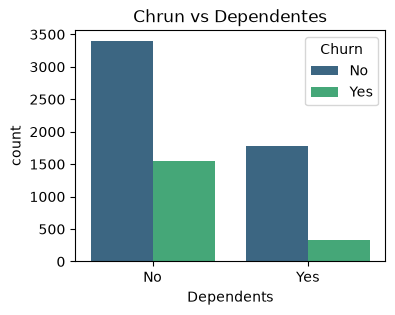

In [123]:
plt.figure(figsize=(4,3))
sns.countplot(data, x='Dependents', hue='Churn', palette='viridis')
plt.title('Chrun vs Dependentes')
plt.show()

* Clientes sem dependentes demonstram uma maior taxa de Churn comparado a clientes que possuem dependentes.

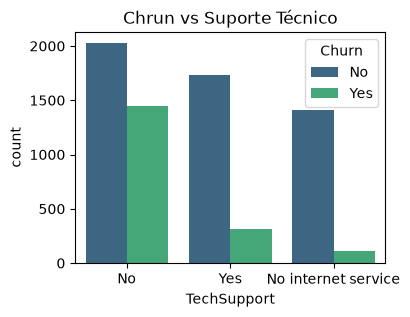

In [126]:
plt.figure(figsize=(4,3))
sns.countplot(data, x='TechSupport', hue='Churn', palette='viridis')
plt.title('Chrun vs Suporte Técnico')
plt.show()

* Clientes sem surporte tecnico tem mais tendendia a cancelar o serviço.

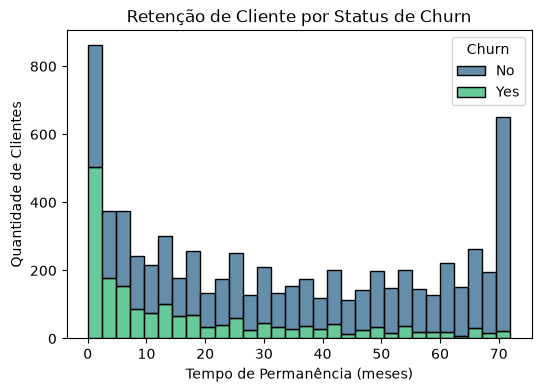

In [109]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='tenure', hue='Churn', bins=30, multiple='stack', palette='viridis')
plt.title('Retenção de Cliente por Status de Churn')
plt.xlabel('Tempo de Permanência (meses)')
plt.ylabel('Quantidade de Clientes')

plt.show()

A distribuição da retenção de clientes apresenta um padrão bimodal: um grande volume de clientes recém-chegados (retenção próximo de 0) e outro grande volume de clientes muito antigos (retenção próximo de 70 meses), com poucos clientes na faixa intermediária. Isso sugere que os primeiros meses de relacionamento são um período crítico de cancelamento, enquanto clientes que superam essa fase inicial tendem a permanecer fiéis por muito tempo.

### Insights:

* Maior parte dos clientes tem o plano de Month-to-month.
* Uma parcela significativa de clientes cancelou o serviço logo no inicio do relacionamento com a empresa.
* Maior parte dos clientes escolheu Fiber Optic.

## Hipótese 1: Tipo de Contrato Influencia no Churn
Para testar a hipótese de que o tipo de contrato influencia o churn, comparamos a distribuição de cancelamentos entre os diferentes tipos de contrato (Contract). Utilizamos um gráfico de contagem para visualizar a quantidade de clientes que cancelaram ou não em cada tipo de contrato, além de uma tabela de proporções para avaliar a taxa de churn relativa dentro de cada grupo.

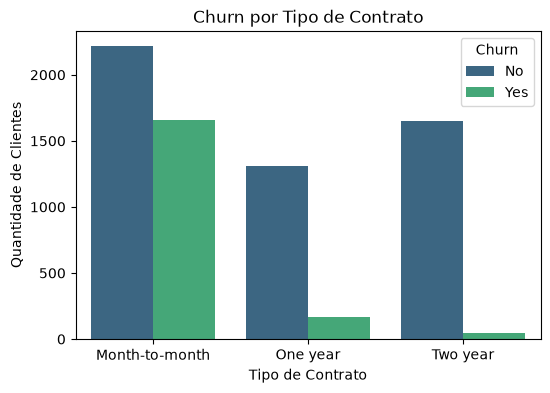

In [112]:
# Gráfico de contagem
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Contract', hue='Churn', palette='viridis') # hue separa as barras por quem cancelou (Yes) e quem não cancelou (No)
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')

plt.show()

In [ ]:
churn_by_contract = pd.crosstab(data['Contract'], data['Churn'], normalize='index') * 100
print(churn_by_contract)

# pd.crosstab -> cria uma tabela cruzada entre Contract e Churn.
# normalize='index' -> transforma os valores em porcentagem dentro de cada linha (ou seja, dentro de cada tipo de contrato), facilitando a comparação.
# * 100 -> converte de proporção (0 a 1) para porcentagem (0 a 100).

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


* **Churn alto para clientes com contrato Month-to-Month:** Clientes com contratos mensais têm a maior taxa de cancelamento, indicando que clientes com contratos flexíveis de curto prazo têm maior probabilidade de sair.
* **Churn menor para contratos de 1 ou 2 anos:** Clientes com contratos de um e dois anos mostram uma rotatividade significativamente menor, sugerindo que contratos com maior tempo de compromisso ajudam na retenção.

## Hipótese 2: O Tipo de Serviço Oferecido Influencia no Churn

Na Hipótese 1, vimos que o tipo de contrato influencia fortemente o churn. Agora investigamos se o serviço oferecido ao cliente também tem um papel importante, considerando o tipo de internet contratada, a presença de suporte técnico e se o cliente possui dependentes. A ideia é entender se a qualidade e abrangência do serviço prestado afetam a decisão do cliente de permanecer ou cancelar.

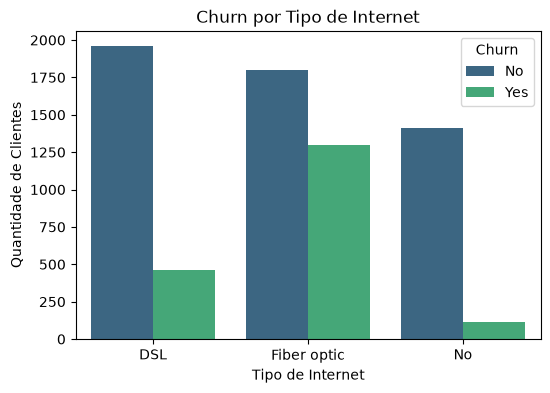

In [113]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='InternetService', hue='Churn', palette='viridis')
plt.title('Churn por Tipo de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [56]:
churn_by_internet = pd.crosstab(data['InternetService'], data['Churn'], normalize='index') * 100
print(churn_by_internet)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


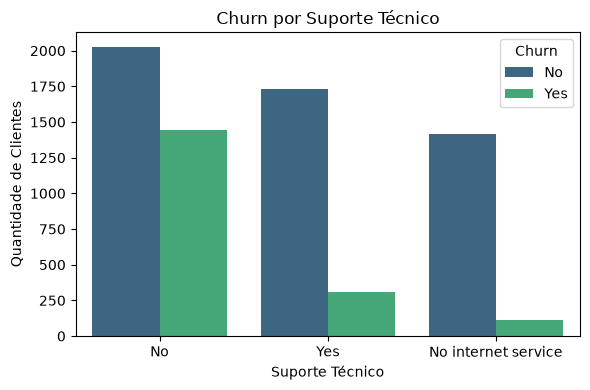

In [140]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='TechSupport', hue='Churn', palette=('viridis'))
plt.title('Churn por Suporte Técnico')
plt.xlabel('Suporte Técnico')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()

In [141]:
churn_by_techsupport = pd.crosstab(data['TechSupport'], data['Churn'], normalize='index') * 100
print(churn_by_techsupport)

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


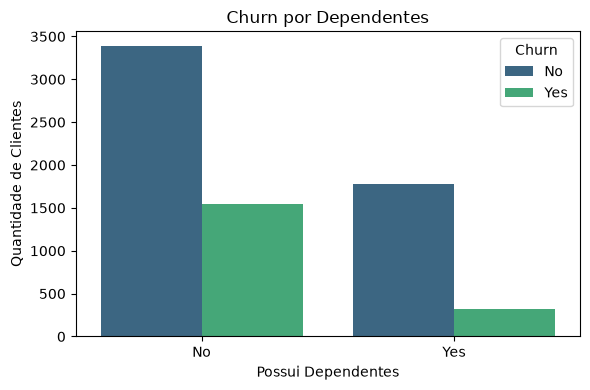

In [142]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Dependents', hue='Churn', palette=('viridis'))
plt.title('Churn por Dependentes')
plt.xlabel('Possui Dependentes')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()

In [143]:
churn_by_dependents = pd.crosstab(data['Dependents'], data['Churn'], normalize='index') * 100
print(churn_by_dependents)

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


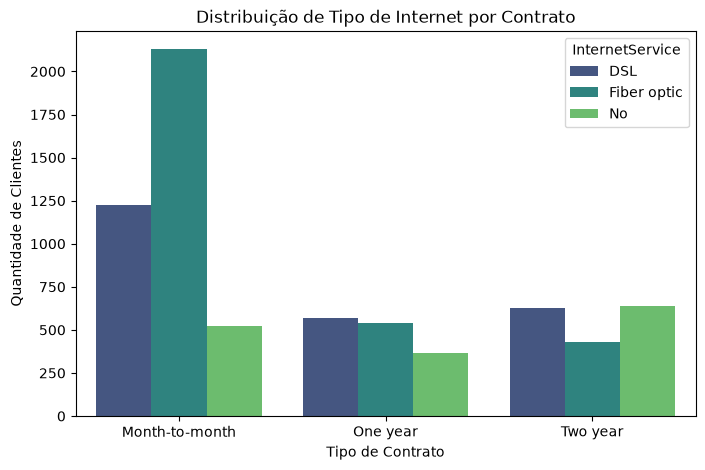

In [114]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Contract', hue='InternetService', palette='viridis')
plt.title('Distribuição de Tipo de Internet por Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [59]:
churn_contract_internet = pd.crosstab(
    [data['Contract'], data['InternetService']], 
    data['Churn'], 
    normalize='index'
) * 100
print(churn_contract_internet)

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699


Os resultados confirmam que o serviço oferecido ao cliente influencia fortemente o churn. Clientes com Fiber Optic e sem suporte técnico apresentam as maiores taxas de cancelamento (~42% em ambos os casos), enquanto clientes sem dependentes no plano também mostram maior propensão ao churn (~31% vs ~16%). Esses achados sugerem que tanto a qualidade/custo do serviço técnico quanto o perfil familiar do cliente estão associados ao nível de comprometimento com a empresa, reforçando a importância de ações de suporte proativo e planos mais flexíveis para clientes individuais.

## Hipótese 3: Método de Pagamento e Cobranças Influenciam o Churn

Após confirmar que o tipo de contrato e o serviço de internet influenciam o churn, investigamos se a forma como o cliente paga e os valores cobrados também têm relação com o cancelamento. A ideia é entender se métodos de pagamento mais "manuais" e cobranças mais altas tornam o cliente mais propenso a sair.

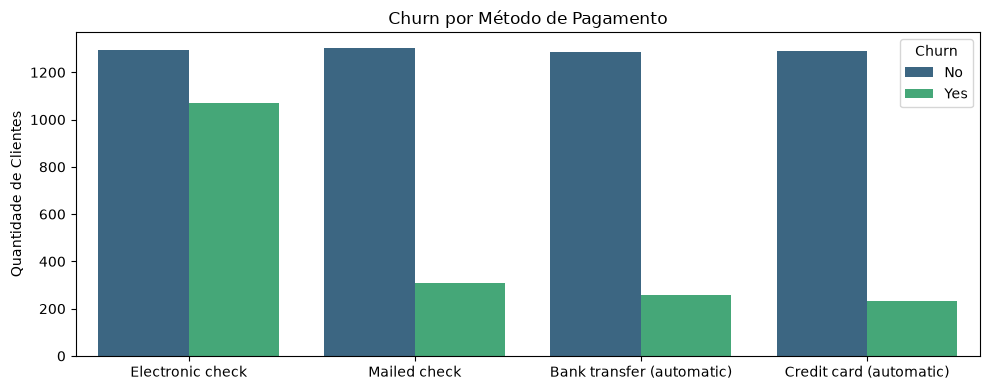

In [132]:
plt.figure(figsize=(10,4))
sns.countplot(data=data, x='PaymentMethod', hue='Churn', palette=('viridis'))
plt.title('Churn por Método de Pagamento')
plt.xlabel(None)
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()

In [ ]:
churn_by_payment = pd.crosstab(data['PaymentMethod'], data['Churn'], normalize='index') * 100
print(churn_by_payment)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


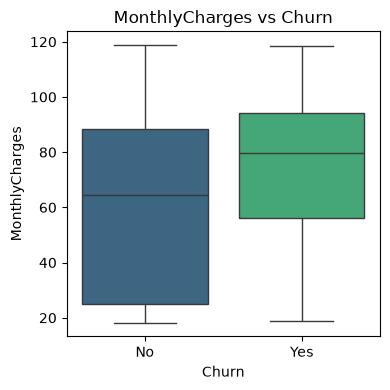

In [136]:
plt.figure(figsize=(4,4))
sns.boxplot(data=data, x='Churn', y='MonthlyCharges', palette=('viridis'))
plt.title('MonthlyCharges vs Churn')
plt.tight_layout()
plt.show()

In [137]:
print(data.groupby('Churn')['MonthlyCharges'].median())

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


In [138]:
churn_payment_charges = data.groupby(['PaymentMethod', 'Churn'])['MonthlyCharges'].median().unstack()
print(churn_payment_charges)

Churn                          No     Yes
PaymentMethod                            
Bank transfer (automatic)  69.475  82.075
Credit card (automatic)    69.950  80.575
Electronic check           79.800  81.950
Mailed check               25.400  53.525


## Ranking dos Perfis de Cliente com Maior Risco de Churn

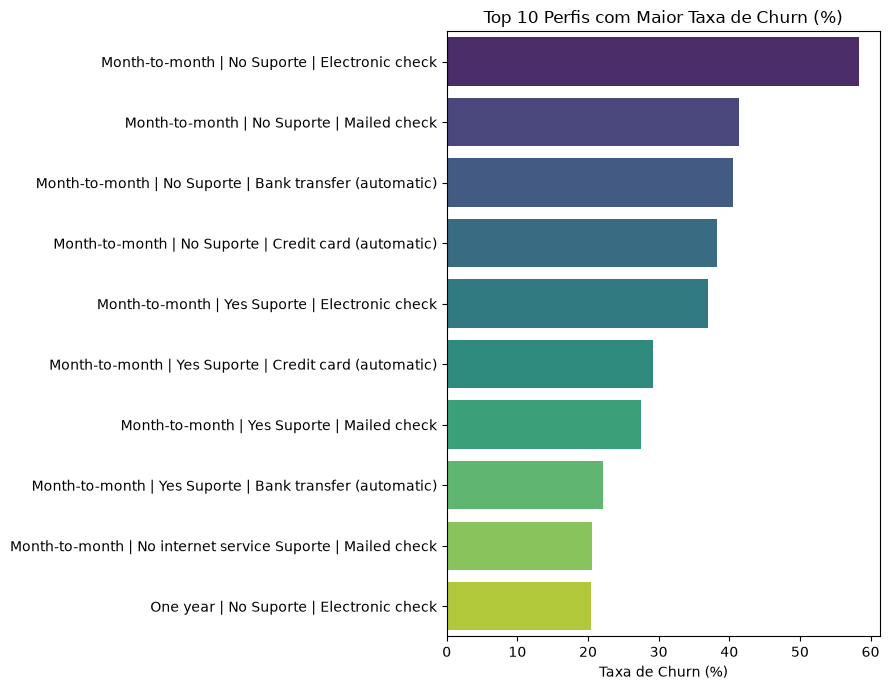

In [147]:
churn_data = data.copy() # copia o dataframe
churn_data['Churn_num'] = churn_data['Churn'].map({'Yes': 1, 'No': 0}) # transforma Yes/No na coluna Churn em 1 e 0

risk_profile = (
    churn_data.groupby(['Contract', 'TechSupport', 'PaymentMethod'])
    .agg(taxa_churn=('Churn_num', 'mean'), qtd_clientes=('Churn_num', 'size')) # calcula a média de Churn_num no grupo, que é a taxa de churn e a quantidade de clientes naquele grupo.
    .reset_index() # transforma as colunas usadas no groupby que viram "índice" por padrão de volta em colunas normais do dataframe.
)

risk_profile = risk_profile[risk_profile['qtd_clientes'] >= 20] # filtra o DataFrame, mantendo apenas os grupos que têm pelo menos 20 clientes, pois um grupo com poucos clientes pode ter uma taxa de churn "extrema", sem representar um padrão real. Esse filtro evita que esses grupos "raros" distorçam o ranking.

risk_profile['taxa_churn'] *= 100 # multiplica a taxa de churn por 100, convertendo de proporção (0 a 1) para porcentagem (0 a 100).
risk_profile['Perfil'] = (
    risk_profile['Contract'] + ' | ' +
    risk_profile['TechSupport'] + ' Suporte | ' +
    risk_profile['PaymentMethod']
)

# Cria uma nova coluna chamada Perfil, que junta as 3 variáveis em um único texto descritivo. Essa coluna vai servir como rótulo no eixo do gráfico, para identificar cada combinação de forma legível.


risk_profile = risk_profile.sort_values('taxa_churn', ascending=False) # ordena a tabela da maior taxa para a menor

plt.figure(figsize=(9,7))
sns.barplot(data=risk_profile.head(10), y='Perfil', x='taxa_churn', hue='Perfil', palette='viridis', legend=False)
plt.title('Top 10 Perfis com Maior Taxa de Churn (%)')
plt.xlabel('Taxa de Churn (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()